## Importing Required Library

In [148]:
import joblib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

## Loading the Dataset

In [149]:
df=pd.read_csv(r'/kaggle/input/cardiovascular-disease-dataset/cardio_train.csv',sep=';')
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


## Data Preprocessing

In [150]:
df.drop('id',axis=1,inplace=True)

In [151]:
df.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [152]:
df["age"] = df["age"] / 365
df

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,50.391781,2,168,62.0,110,80,1,1,0,0,1,0
1,55.419178,1,156,85.0,140,90,3,1,0,0,1,1
2,51.663014,1,165,64.0,130,70,3,1,0,0,0,1
3,48.282192,2,169,82.0,150,100,1,1,0,0,1,1
4,47.873973,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52.712329,2,168,76.0,120,80,1,1,1,0,1,0
69996,61.920548,1,158,126.0,140,90,2,2,0,0,1,1
69997,52.235616,2,183,105.0,180,90,3,1,0,1,0,1
69998,61.454795,1,163,72.0,135,80,1,2,0,0,0,1


## Data Cleaning

In [153]:
df = df[(df['height'] > 120) & (df['height'] < 220)]

df = df[(df['weight'] > 30) & (df['weight'] < 200)]

df = df[(df['ap_hi'] > 50) & (df['ap_hi'] < 250)]
df = df[(df['ap_lo'] > 30) & (df['ap_lo'] < 200)]

df = df[df['ap_hi'] > df['ap_lo']]

## Feature Engineering

In [154]:
df['BMI'] = df['weight'] / (df['height'] / 100) ** 2
df['BMI']

0        21.967120
1        34.927679
2        23.507805
3        28.710479
4        23.011177
           ...    
69995    26.927438
69996    50.472681
69997    31.353579
69998    27.099251
69999    24.913495
Name: BMI, Length: 68579, dtype: float64

In [155]:
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

## Exploratory Data Analysis (EDA)

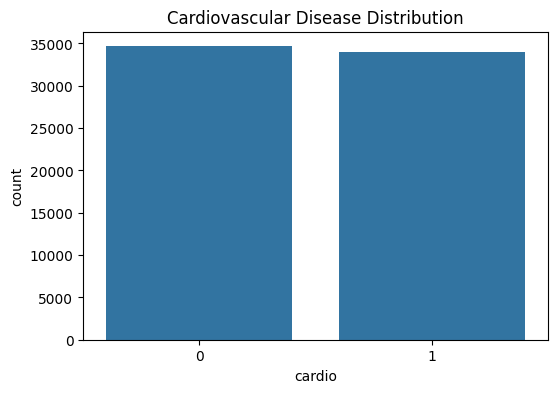

In [156]:
plt.figure(figsize=(6,4))
sns.countplot(x='cardio', data=df)
plt.title("Cardiovascular Disease Distribution")
plt.show()

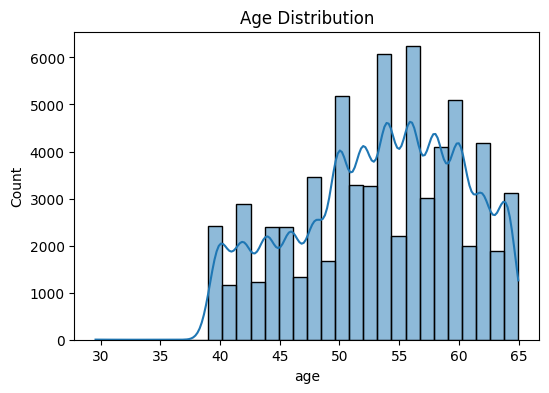

In [157]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

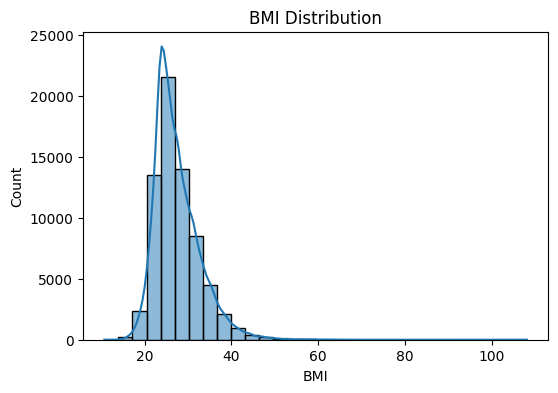

In [158]:
plt.figure(figsize=(6,4))
sns.histplot(df['BMI'], bins=30, kde=True)
plt.title("BMI Distribution")
plt.show()

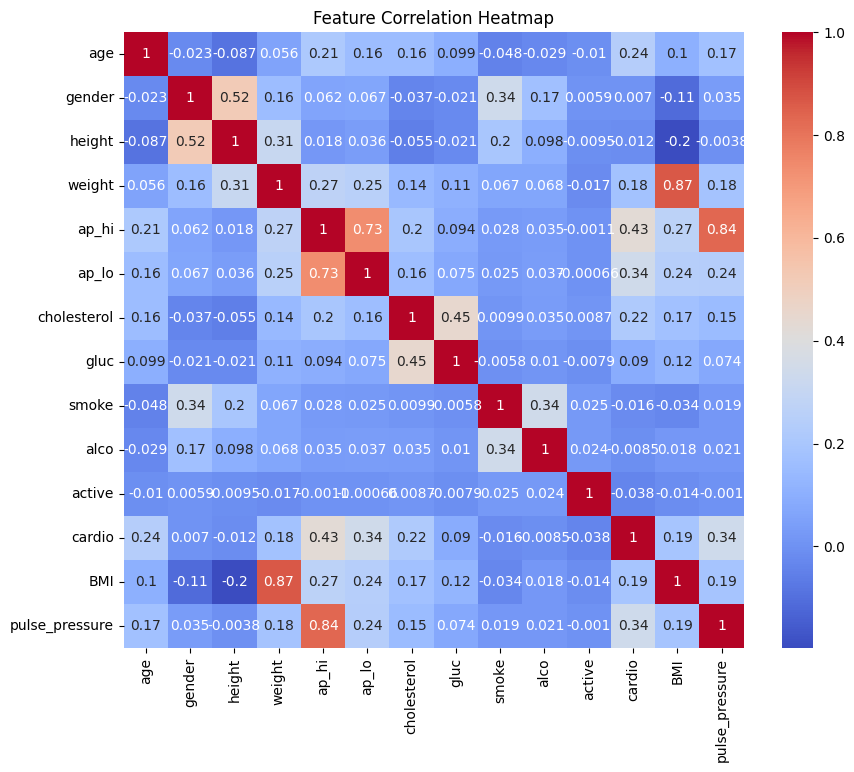

In [159]:
plt.figure(figsize=(10,8))
corr = df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [160]:
df.drop('weight',axis=1,inplace=True)

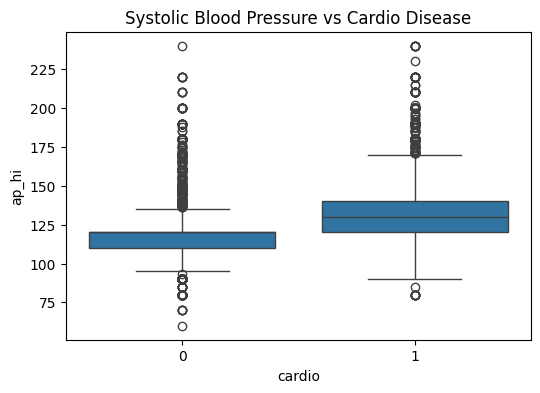

In [161]:
plt.figure(figsize=(6,4))
sns.boxplot(x='cardio', y='ap_hi', data=df)
plt.title("Systolic Blood Pressure vs Cardio Disease")
plt.show()

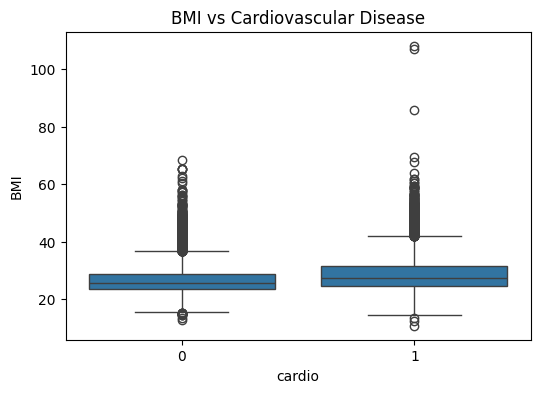

In [162]:
plt.figure(figsize=(6,4))
sns.boxplot(x='cardio', y='BMI', data=df)
plt.title("BMI vs Cardiovascular Disease")
plt.show()

## Feature Selection

In [163]:
X = df.drop("cardio", axis=1)  
y = df["cardio"]               

## Train-Test Split

In [164]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Training

In [165]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4
)

In [166]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=300, random_state=42)

## Model Evaluation

In [167]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.80      0.76      6946
           1       0.77      0.67      0.72      6770

    accuracy                           0.74     13716
   macro avg       0.74      0.74      0.74     13716
weighted avg       0.74      0.74      0.74     13716

0.7370953630796151


## Model Testing with Sample Patients

In [168]:
def test_patient(sample):

    df = pd.DataFrame([sample])

    df["BMI"] = df["weight"] / (df["height"]/100)**2
    df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]

    df = df[X.columns]

    prediction = rf.predict(df.values)[0]
    prob = rf.predict_proba(df.values)[0][1]

    print("Prediction:", prediction)
    print("Risk Probability:", prob)




In [169]:
samples = [{
    "age": 22,
    "gender": 1,
    "height": 165,
    "weight": 55,
    "ap_hi": 105,
    "ap_lo": 65,
    "cholesterol": 1,
    "gluc": 1,
    "smoke": 0,
    "alco": 0,
    "active": 1
},{
    "age": 35,
    "gender": 2,
    "height": 175,
    "weight": 82,
    "ap_hi": 125,
    "ap_lo": 80,
    "cholesterol": 2,
    "gluc": 1,
    "smoke": 0,
    "alco": 1,
    "active": 0
}, {
    "age": 48,
    "gender": 2,
    "height": 170,
    "weight": 90,
    "ap_hi": 150,
    "ap_lo": 95,
    "cholesterol": 2,
    "gluc": 2,
    "smoke": 1,
    "alco": 1,
    "active": 0
}, {
    "age": 60,
    "gender": 1,
    "height": 160,
    "weight": 95,
    "ap_hi": 170,
    "ap_lo": 110,
    "cholesterol": 3,
    "gluc": 2,
    "smoke": 1,
    "alco": 1,
    "active": 0
},{
    "age": 65,
    "gender": 2,
    "height": 168,
    "weight": 110,
    "ap_hi": 190,
    "ap_lo": 120,
    "cholesterol": 3,
    "gluc": 3,
    "smoke": 1,
    "alco": 1,
    "active": 0
}] 

In [170]:
for sample in samples:
    test_patient(sample)

Prediction: 0
Risk Probability: 0.0803245403431838
Prediction: 0
Risk Probability: 0.3484459389233942
Prediction: 1
Risk Probability: 0.853816328886132


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

Prediction: 1
Risk Probability: 0.8672243520050102
Prediction: 1
Risk Probability: 0.7899901318887845


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


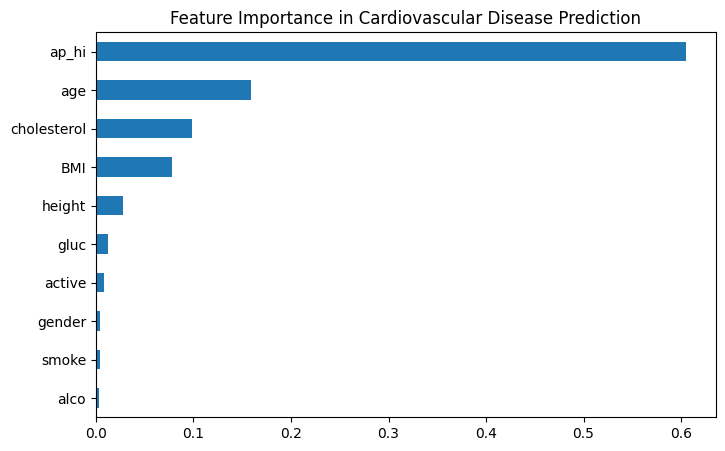

In [171]:
importance.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance in Cardiovascular Disease Prediction")
plt.show()

In [172]:
model_data = {
    "model": rf,
    "columns": X.columns.tolist()
}

joblib.dump(model_data, "cardio_random_forest_model.pkl")

print("Model saved successfully!")

Model saved successfully!
